# Relative Permeability: Pipeline vs Parente (2025)
### A reproducible comparison notebook (methane experiment)

Every number and figure in this notebook is produced by the code cells below.
The pipeline results are read from the DuckDB database; Parente's values are read
from her data workbook **and** cross-checked against her thesis tables.

**Sources**
- Pipeline: `results.duckdb` (this study).
- Parente experimental data: `Methane_-_Data_processing.xlsx`, sheet `Complete tables`.
- Parente thesis (for method, equations, and cross-checking): Parente (2025),
  *Relative permeability ... underground hydrogen storage*, PoliMi MSc thesis.
  Cited below as **[thesis, p.N]**.

**Open question flagged up front (see Section 3):** Parente's water saturation is
reported differently in her workbook column vs her thesis Table 3.7. Both readings
are shown; the choice is left open.


## 1. Setup and data sources

In [6]:
import duckdb
import numpy as np
import statistics as st
from collections import defaultdict
import matplotlib.pyplot as plt

# ---- EDIT THESE PATHS to match your machine ----
DB_PATH      = r"results.duckdb"
PARENTE_XLSX = r"Methane - Data processing.xlsx"
CONNECTIVITY = "18N"

M2_TO_MDARCY = 1000.0 / 9.869233e-13   # convert m^2 -> milliDarcy
print("paths set; matplotlib ready")

paths set; matplotlib ready


## 2. Load the pipeline results from the database

For each (section, scan) the pipeline stored GeoDict permeabilities. Relative
permeability is a simple division, **kr = K_eff / K_abs(section)**, with the
section's absolute permeability as a fixed denominator across all its timesteps
[thesis, p.38: "the absolute permeability is obtained considering that one single
fluid flows in the pore space"; effective permeability treats the other phase as
rock].


In [7]:
con = duckdb.connect(DB_PATH, read_only=True)
run_id = con.execute("SELECT run_id FROM runs ORDER BY rowid DESC LIMIT 1").fetchone()[0]

rows = con.execute('''
    SELECT track_id, scan_index, sim_type, k_z, Sw
    FROM simulation_results
    WHERE run_id = ? AND connectivity = ? AND simulator = 'GeoDict'
''', [run_id, CONNECTIVITY]).fetchall()

# per-section absolute permeability + Z-extent (REV proxy)
zext = {tr: (z1 - z0) for tr, z0, z1 in con.execute(
    "SELECT DISTINCT track_id, z0, z1 FROM fixed_boxes WHERE connectivity = ?",
    [CONNECTIVITY]).fetchall() if z0 is not None and z1 is not None}
global_sw = dict(con.execute("SELECT scan_index, Sw FROM scans WHERE Sw IS NOT NULL").fetchall())
con.close()

kabs, cell = {}, {}
for tr, sc, sty, kz, sw in rows:
    if sty == "absolute":
        kabs[tr] = kz
    else:
        d = cell.setdefault((tr, sc), {"g": None, "w": None, "sw": None})
        if sty == "gas":   d["g"] = kz
        if sty == "water": d["w"] = kz
        if sw is not None: d["sw"] = sw

pipe = []   # one dict per (section, scan)
for (tr, sc), d in cell.items():
    ka = kabs.get(tr)
    pipe.append(dict(section=tr, scan=sc, Sw=d["sw"],
                     kr_gas=(d["g"]/ka if (ka and d["g"] is not None) else None),
                     kr_brine=(d["w"]/ka if (ka and d["w"] is not None) else None),
                     z_extent=zext.get(tr)))
kabs_mD = {tr: kabs[tr]*M2_TO_MDARCY for tr in kabs}

print(f"run_id = {run_id}")
print(f"loaded {len(pipe)} (section,scan) points across {len(kabs)} sections")
print("per-section K_abs (mD):", {k: round(v) for k, v in sorted(kabs_mD.items())})

run_id = 20260618_155713_AMSDS99619
loaded 72 (section,scan) points across 6 sections
per-section K_abs (mD): {1: 683, 2: 618, 3: 739, 4: 1018, 5: 636, 6: 568}


## 3. Load Parente's data — and the saturation discrepancy

Parente's per-section experimental values come from her workbook. The kr values
match her thesis Table 3.7 exactly, which validates the workbook. **However, the
water-saturation column does not agree between the two sources**, so we load both
readings and keep them side by side.

- **Reading A (workbook column N, labelled `Sw`):** Sw ≈ 0.53–0.56 at the fluid
  steps. This is what makes the pipeline and Parente overlap closely.
- **Reading B (thesis Table 3.7, column `Sw`):** Sw ≈ 0.44–0.47 at the same steps.

The kr numbers are identical between sources; only the saturation label differs.
In the workbook, column M (`Sg`) equals the thesis `Sw`, and column N (`Sw`) equals
the thesis `Sg` — i.e. the two columns are transposed relative to the thesis. We do
**not** resolve which is correct here; it is an open question [thesis Table 3.7,
p.66 vs workbook `Complete tables` cols M/N].


In [8]:
import openpyxl
wb = openpyxl.load_workbook(PARENTE_XLSX, data_only=True)
ws = wb["Complete tables"]

def _num(v):
    try:    return float(v)
    except (TypeError, ValueError): return None

par = []          # per (section, scan)
par_kabs = []     # per-section K_abs (mD)
cur = None
for r in range(5, ws.max_row + 1):
    sec = ws.cell(r, 3).value
    if sec: cur = sec
    scan = ws.cell(r, 4).value
    ka  = _num(ws.cell(r, 5).value)    # E  Abs perm (GD)  [mD]
    krg = _num(ws.cell(r, 11).value)   # K  Rel perm H2 (gas)
    krw = _num(ws.cell(r, 12).value)   # L  Rel perm brine
    sg_col = _num(ws.cell(r, 13).value)  # M  labelled 'Sg' (== thesis Sw)
    sw_col = _num(ws.cell(r, 14).value)  # N  labelled 'Sw' (== thesis Sg)
    if ka is not None and scan == 0:
        par_kabs.append(ka)
    if scan not in (0, None) and sw_col is not None:
        par.append(dict(section=cur, scan=scan, kr_gas=krg, kr_brine=krw,
                        Sw_readingA=sw_col,      # workbook col N
                        Sw_readingB=sg_col))     # workbook col M == thesis Sw

print(f"loaded {len(par)} Parente fluid-step points, {len(par_kabs)} per-section K_abs")
print("Reading A (workbook 'Sw') mean:", round(st.mean(p['Sw_readingA'] for p in par) if False else
      st.mean([p['Sw_readingA'] for p in par]), 3))
print("Reading B (thesis  'Sw') mean:", round(st.mean([p['Sw_readingB'] for p in par]), 3))

loaded 24 Parente fluid-step points, 8 per-section K_abs
Reading A (workbook 'Sw') mean: 0.563
Reading B (thesis  'Sw') mean: 0.437


## 4. Variable roles

- **Independent (controlled):** water saturation `Sw` — the x-axis throughout.
- **Dependent (measured):** `kr_gas`, `kr_brine`, `K_abs`.
- **Grouping / nuisance:** axial section, section Z-extent (REV proxy), timestep.

Because `kr` depends strongly on `Sw`, comparisons are made on the saturation axis,
not by scan number (the pipeline and Parente number scans differently — different
experiments).


## 5. Aggregation: per-timestep (per-saturation) averages

Each timestep is effectively one saturation level, so we average its sections into a
single `(mean Sw, mean kr ± sd)` point. We lead with this **per-saturation** average
rather than a single overall pooled mean, because pooling across saturations mixes
points that should be compared at matching `Sw`.


In [9]:
def per_timestep(points, sw_key):
    by = defaultdict(list)
    for p in points:
        sw = p.get(sw_key)
        if sw is not None:
            by[p["scan"]].append(p)
    out = []
    for scan in sorted(by):
        e = by[scan]
        def ms(key):
            v = [p[key] for p in e if p.get(key) is not None]
            return (st.mean(v), st.pstdev(v) if len(v) > 1 else 0.0) if v else (None, None)
        sw_m, sw_s = ms(sw_key)
        g_m, g_s = ms("kr_gas")
        w_m, w_s = ms("kr_brine")
        out.append(dict(scan=scan, n=len(e), Sw=sw_m, Sw_sd=sw_s,
                        kr_gas=g_m, kr_gas_sd=g_s, kr_brine=w_m, kr_brine_sd=w_s))
    return out

pipe_ts = per_timestep(pipe, "Sw")
print(f"{'scan':>4} {'n':>3} {'Sw':>7} {'kr_gas':>16} {'kr_brine':>16}")
for r in pipe_ts:
    print(f"{r['scan']:>4} {r['n']:>3} {r['Sw']:>7.3f} "
          f"{r['kr_gas']:>8.4f}±{r['kr_gas_sd']:.4f} "
          f"{r['kr_brine']:>8.4f}±{r['kr_brine_sd']:.4f}")

scan   n      Sw           kr_gas         kr_brine
   0   6   0.285   0.2487±0.0448   0.0044±0.0028
   1   6   0.546   0.0687±0.0413   0.0678±0.0132
   2   6   0.543   0.0662±0.0308   0.0577±0.0078
   3   6   0.553   0.0637±0.0315   0.0749±0.0200
   4   6   0.577   0.0536±0.0332   0.0956±0.0287
   5   6   0.575   0.0548±0.0353   0.0843±0.0198
   6   6   0.592   0.0469±0.0252   0.0981±0.0176
   7   6   0.614   0.0410±0.0237   0.1051±0.0135
   8   6   0.634   0.0435±0.0316   0.1409±0.0167
   9   6   0.651   0.0363±0.0259   0.1600±0.0362
  10   6   0.672   0.0319±0.0322   0.1751±0.0251
  11   6   0.935   0.0188±0.0148   0.2984±0.0627


## 6. Is per-timestep averaging justified? Saturation coherence

Averaging sections at a timestep is valid only if they sit at nearly the same
saturation. The plot below shows each section's `Sw` (dots), their mean (line), and
the global whole-volume `Sw` (dashed). The right panel shows the spread.


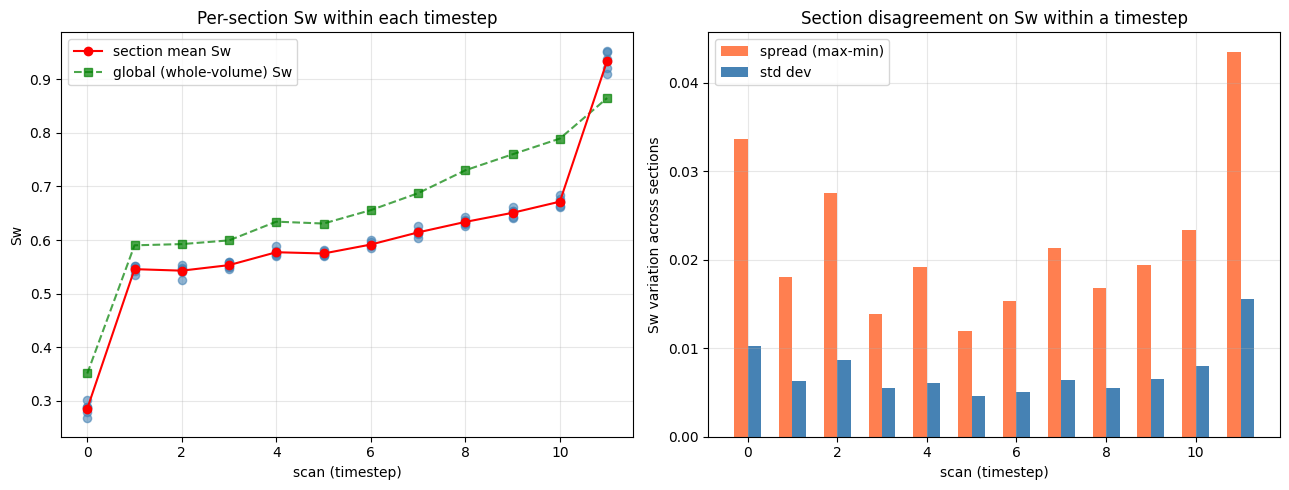

mean per-timestep section spread: 0.022 Sw
global Sw runs on average +0.059 above the per-section mean (inlet/outlet effect)


In [10]:
by_scan = defaultdict(list)
for p in pipe:
    if p["Sw"] is not None:
        by_scan[p["scan"]].append(p["Sw"])
scans = sorted(by_scan)
sec_mean = [st.mean(by_scan[s]) for s in scans]
sec_spread = [max(by_scan[s]) - min(by_scan[s]) for s in scans]
sec_std = [st.pstdev(by_scan[s]) if len(by_scan[s]) > 1 else 0 for s in scans]
glob = [global_sw.get(s, np.nan) for s in scans]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
for s in scans:
    a1.scatter([s]*len(by_scan[s]), by_scan[s], color="steelblue", alpha=0.6, s=35, zorder=3)
a1.plot(scans, sec_mean, "r-o", label="section mean Sw", zorder=4)
a1.plot(scans, glob, "g--s", alpha=0.7, label="global (whole-volume) Sw")
a1.set_xlabel("scan (timestep)"); a1.set_ylabel("Sw")
a1.set_title("Per-section Sw within each timestep"); a1.legend(); a1.grid(alpha=0.3)
a2.bar([s-0.15 for s in scans], sec_spread, width=0.3, label="spread (max-min)", color="coral")
a2.bar([s+0.15 for s in scans], sec_std, width=0.3, label="std dev", color="steelblue")
a2.set_xlabel("scan (timestep)"); a2.set_ylabel("Sw variation across sections")
a2.set_title("Section disagreement on Sw within a timestep"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"mean per-timestep section spread: {st.mean(sec_spread):.3f} Sw")
print(f"global Sw runs on average {st.mean([g-m for g,m in zip(glob, sec_mean)]):+.3f} "
      f"above the per-section mean (inlet/outlet effect)")

## 7. Absolute permeability: distribution vs distribution

`K_abs` is compared as a distribution of per-section values (not against a single
whole-volume number, which would mix spatial scales).


pipeline K_abs: n=6 mean=710 mD range 568-1018
Parente  K_abs: n=8 mean=720 mD range 549-945
mean difference: -9 mD (-1.3%)


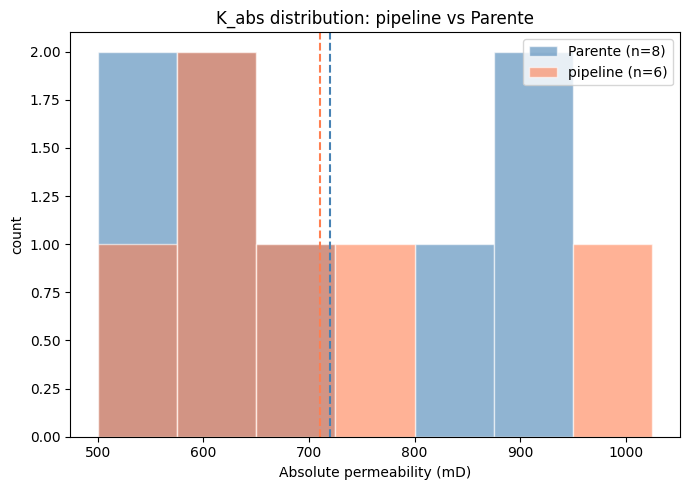

In [11]:
my_k = list(kabs_mD.values())
print(f"pipeline K_abs: n={len(my_k)} mean={st.mean(my_k):.0f} mD range {min(my_k):.0f}-{max(my_k):.0f}")
print(f"Parente  K_abs: n={len(par_kabs)} mean={st.mean(par_kabs):.0f} mD range {min(par_kabs):.0f}-{max(par_kabs):.0f}")
print(f"mean difference: {st.mean(my_k)-st.mean(par_kabs):+.0f} mD "
      f"({(st.mean(my_k)-st.mean(par_kabs))/st.mean(par_kabs)*100:+.1f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
bins = np.arange(500, 1075, 75)
ax.hist(par_kabs, bins=bins, alpha=0.6, color="steelblue", label=f"Parente (n={len(par_kabs)})", edgecolor="white")
ax.hist(my_k, bins=bins, alpha=0.6, color="coral", label=f"pipeline (n={len(my_k)})", edgecolor="white")
ax.axvline(st.mean(par_kabs), color="steelblue", ls="--")
ax.axvline(st.mean(my_k), color="coral", ls="--")
ax.set_xlabel("Absolute permeability (mD)"); ax.set_ylabel("count")
ax.set_title("K_abs distribution: pipeline vs Parente"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Parente's Corey model(s)

Parente fits two models to the methane data [thesis Section 3.3]:

- **Standard Corey (Table 3.8, p.68):** krw0=0.1381, krn0=0.9467, nw=3.861, nn=2.154.
- **Modified Corey (Table 3.9, p.71):** krw0=0.1381, krn0=0.7699, nw=3.861, nn=3.339,
  cn=0.2946, cw=0. This is her *improved* model — the `cn` term lifts the gas tail to
  better fit the high-Sw points the standard model missed [thesis p.69].

Equations [thesis Eqs 2.5–2.11, p.44–45]:

Rescaled saturation: `Sr = (Sw - Swc)/(1 - Swc - Snr)`

Standard:  `kr_w = krw0·Sr^nw`,  `kr_n = krn0·(1-Sr)^nn`

Modified:  adds `+(c/(1+c))·(...)` tail terms; cw=0 so brine stays standard.

> **Uncertainty:** Eq 2.10 contains a residual term `Sor` carried from an oil-system
> reference [thesis p.45, ref 61]. Parente's experiment has no oil. Testing against
> her own gas points selects `Sor = Snr = 0.39` (it reproduces her points; other
> values do not), so that is used here, but the choice is an inference, not a value
> she states explicitly for the gas/brine case.


In [12]:
STD = dict(Swc=0.0, Snr=0.39, krw0=0.1381, krn0=0.9467, nw=3.861, nn=2.154)
MOD = dict(Swc=0.0, Snr=0.39, krw0=0.1381, krn0=0.7699, nw=3.861, nn=3.339, cn=0.2946, cw=0.0)

def corey_standard(sw, P):
    Sr = np.clip((sw - P["Swc"])/(1 - P["Swc"] - P["Snr"]), 0, 1)
    return P["krw0"]*Sr**P["nw"], P["krn0"]*(1 - Sr)**P["nn"]

def corey_modified(sw, P, Sor=None):
    Sor = P["Snr"] if Sor is None else Sor
    base_n = np.clip((1 - sw - Sor)/(1 - P["Swc"] - Sor), 0, 1)
    base_w = np.clip((sw - P["Swc"])/(1 - P["Swc"] - P["Snr"]), 0, 1)
    kr_n = P["krn0"]*base_n**P["nn"] + (P["cn"]/(1+P["cn"]))*base_n
    kr_w = P["krw0"]*base_w**P["nw"] + (P["cw"]/(1+P["cw"]))*base_w
    return kr_w, kr_n

# verify the modified model reproduces her experimental gas points (reading-independent: kr only)
sw_pts = np.array([p["Sw_readingA"] for p in par])      # x only used for evaluation
krg_pts = np.array([p["kr_gas"] for p in par])
_, krn_pred = corey_modified(sw_pts, MOD)
rmse = np.sqrt(np.nanmean((krn_pred - krg_pts)**2))
print(f"modified-Corey gas RMSE vs Parente points (reading A x): {rmse:.4f}")

modified-Corey gas RMSE vs Parente points (reading A x): 0.0234


## 9. The comparison figure — shown for BOTH saturation readings

Because the saturation source is unresolved (Section 3), the kr-vs-Sw comparison is
drawn twice: once placing Parente's points at Reading A (workbook `Sw` ≈ 0.55) and
once at Reading B (thesis `Sw` ≈ 0.44). The pipeline points are identical in both;
only Parente's x-positions move. Parente's modified-Corey curve is drawn on the same
saturation convention as her points in each panel.


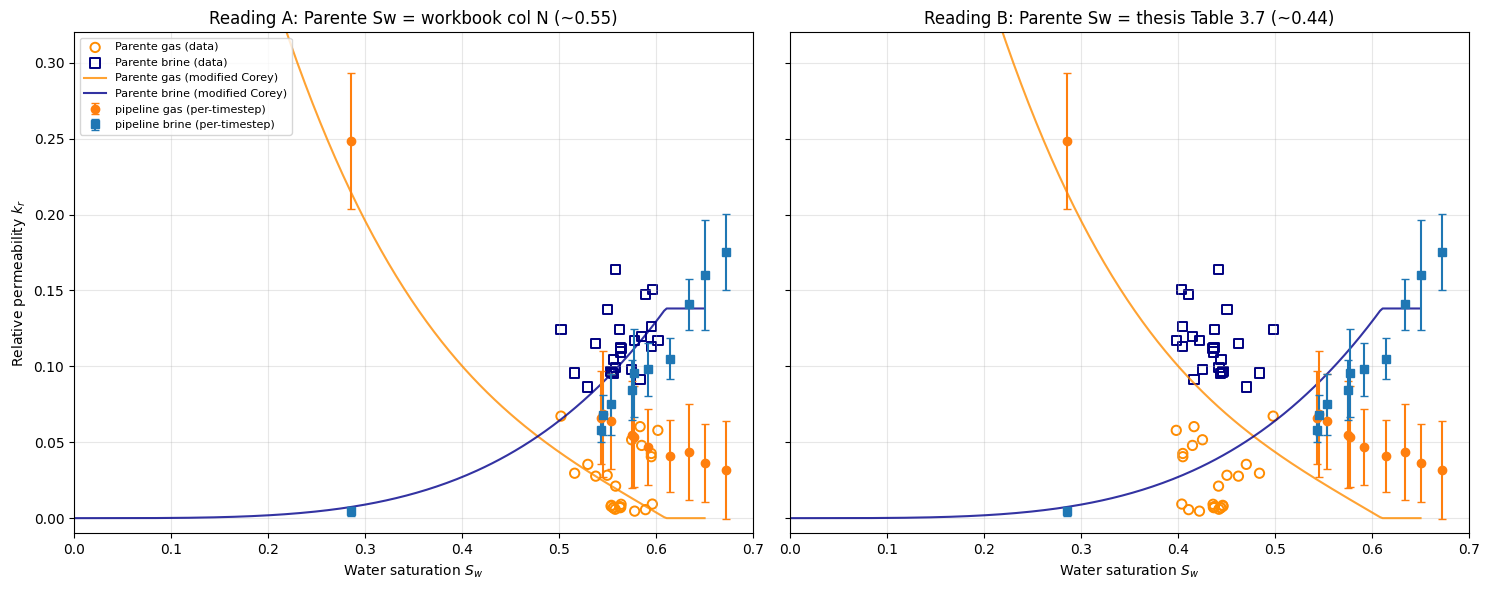

In [14]:
sw_curve = np.linspace(0.001, 0.65, 250)
krw_mod, krn_mod = corey_modified(sw_curve, MOD)
krw_std, krn_std = corey_standard(sw_curve, STD)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, reading, title in [(axes[0], "Sw_readingA", "Reading A: Parente Sw = workbook col N (~0.55)"),
                           (axes[1], "Sw_readingB", "Reading B: Parente Sw = thesis Table 3.7 (~0.44)")]:
    # pipeline per-timestep points (same in both)
    ax.errorbar([r["Sw"] for r in pipe_ts], [r["kr_gas"] for r in pipe_ts],
                yerr=[r["kr_gas_sd"] for r in pipe_ts], fmt="o", color="tab:orange",
                capsize=3, label="pipeline gas (per-timestep)", zorder=5)
    ax.errorbar([r["Sw"] for r in pipe_ts], [r["kr_brine"] for r in pipe_ts],
                yerr=[r["kr_brine_sd"] for r in pipe_ts], fmt="s", color="tab:blue",
                capsize=3, label="pipeline brine (per-timestep)", zorder=5)
    # parente points at this reading
    ax.scatter([p[reading] for p in par], [p["kr_gas"] for p in par],
               facecolors="none", edgecolors="darkorange", s=45, linewidths=1.4, label="Parente gas (data)")
    ax.scatter([p[reading] for p in par], [p["kr_brine"] for p in par],
               marker="s", facecolors="none", edgecolors="navy", s=45, linewidths=1.4, label="Parente brine (data)")
    # her modified curve
    ax.plot(sw_curve, krn_mod, "-", color="darkorange", alpha=0.8, label="Parente gas (modified Corey)")
    ax.plot(sw_curve, krw_mod, "-", color="darkblue", alpha=0.8, label="Parente brine (modified Corey)")
    ax.set_xlim(0, 0.7); ax.set_ylim(-0.01, 0.32)
    ax.set_xlabel("Water saturation $S_w$"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("Relative permeability $k_r$")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 10. Why some sections deviate: the REV effect

Sections vary more than two-fold in Z-extent. Parente deliberately sized her sections
to the smallest cluster and kept them thinner than the clusters to limit size effects
[thesis p.36: "the sections were chosen to be thinner than the clusters ... as ...
including these areas ... might have strong size effects on the final permeability"].
Thin sections risk not containing a Representative Elementary Volume (REV).


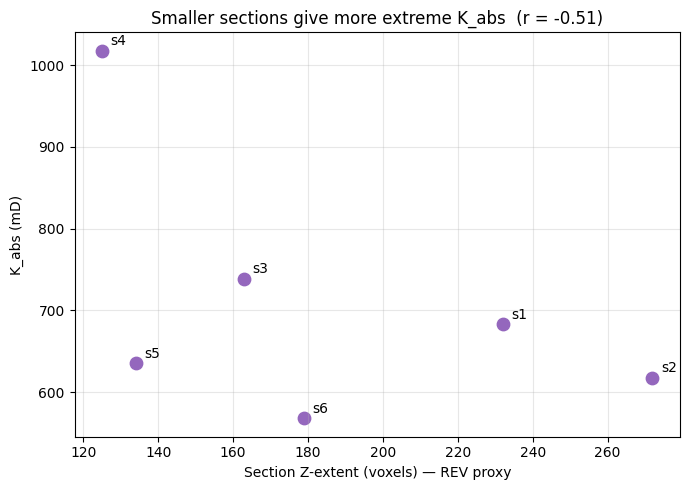

correlation(Z-extent, K_abs) = -0.51
smallest section is the K_abs outlier -> REV effect


In [15]:
secs = sorted(kabs_mD)
zs = [zext[s] for s in secs]
ks = [kabs_mD[s] for s in secs]
r = float(np.corrcoef(zs, ks)[0, 1])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(zs, ks, s=80, c="tab:purple")
for s, z, k in zip(secs, zs, ks):
    ax.annotate(f"s{s}", (z, k), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("Section Z-extent (voxels) — REV proxy"); ax.set_ylabel("K_abs (mD)")
ax.set_title(f"Smaller sections give more extreme K_abs  (r = {r:+.2f})")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"correlation(Z-extent, K_abs) = {r:+.2f}")
print("smallest section is the K_abs outlier -> REV effect")

## 11. Why 12 pipeline timesteps vs Parente's 3

Scope, not method. Parente analysed experiment 8 only for methane (three fluid scans)
[thesis Table 3.7 lists the methane areas of interest]. The pipeline processed
experiments 8–11 stitched into one timeline, extending to higher saturations she did
not sample. The three saturations she reports fall inside the pipeline's range.


## 12. Summary

- **kr is computed identically in spirit** to Parente (K_eff/K_abs per section), and
  the pipeline's per-section method maps to her sectioning procedure.
- **K_abs distributions agree** to ~1% in the mean.
- **kr trends agree** with her modified-Corey curve where they overlap — but the size
  of the overlap depends on the unresolved saturation question (Section 3).
- **Open items flagged:** (i) which saturation reading is correct (workbook ~0.55 vs
  thesis ~0.44); (ii) the `Sor` value in the modified-Corey gas equation is inferred,
  not stated; (iii) the smallest sections are REV-questionable and may be excluded in a
  refined comparison.

All figures above regenerate from the code cells; no external image files are used.
